In [ ]:
import json
from pathlib import Path

# 改这里：选择任务/切分/语言
task = 'sib200'
split = 'train'
lang = 'zh'   # 非 en 才能测 R_align

root = Path('../data_qwen_sample')
files = sorted((root / task / split).glob(f"{lang}_Qwen3-8B_*.jsonl"))
en_files = sorted((root / task / split).glob("en_Qwen3-8B_*.jsonl"))
assert files, 'cannot find lang file'
assert en_files, 'cannot find en file for anchor'

path_lang = files[0]
path_en = en_files[0]
print('lang file:', path_lang)
print('en file:', path_en)

def read_jsonl(p):
    rows = []
    with p.open('r', encoding='utf-8') as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

rows_lang = read_jsonl(path_lang)
rows_en = read_jsonl(path_en)

ex_lang = rows_lang[64]
ex_en = rows_en[64]

# 这里取第 0 个 cf 示例（你要取 gen_id=9 的话改成 [9]）
cf_lang = ex_lang['counterfactual'][lang][0]
cf_en = ex_en['counterfactual']['en'][0]

print('orig index:', ex_lang['index'])
print('orig_pred_text:', ex_lang.get('orig_pred_text', {}).get(lang))
print('target_pred_text:', ex_lang.get('target_pred_text', {}).get(lang))
print('cf_lang:', cf_lang['text'])
print('cf_en(anchor):', cf_en['text'])



In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from reward_pred_aug import eval_one_example

local_model_dir = '/root/autodl-tmp/model/Qwen3-8B'

tokenizer = AutoTokenizer.from_pretrained(local_model_dir, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    local_model_dir,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
)

use_chat_template = False

# 只评估这 1 条样本（只会处理 10 个 counterfactual，并把 reward 写进 ex_lang dict）
eval_one_example(task, lang, ex_lang, model, tokenizer, use_chat_template)

cf9 = ex_lang['counterfactual'][lang][9]

print('orig_pred_text(runtime-from-file):', ex_lang['orig_pred_runtime'][lang])
print('orig_label_logits_first_token:', ex_lang['orig_label_logits'][lang])

print('cf9 pred/conf:', cf9['pred'], cf9['confidence'])
print('cf9 reward_flip:', cf9.get('reward_flip'))
print('cf9 reward_aug_flip/logit_gap_abs_flip:', cf9.get('reward_aug_flip'), cf9.get('logit_gap_abs_flip'))
print('cf9 reward_aug_noflip/logit_gap_abs_noflip:', cf9.get('reward_aug_noflip'), cf9.get('logit_gap_abs_noflip'))



In [ ]:
# 2) 测 R_edit
from reward_edit_lev import reward_edit

if task == 'sib200':
    x = ex_lang['text'][lang]
    x_hat = cf_lang['text']
else:
    x = ex_lang['premise'][lang]
    x_hat = cf_lang['text']

r_edit = reward_edit(x_hat, x)
print('R_edit:', r_edit)


In [ ]:
# 3) 测 R_align（用 NLLB：从 非英语 counterfactual 翻回英语 anchor）
from reward_align_nllb import load_nllb, nllb_ce_loss_and_reward, LANG2NLLB

# 在 notebook cell 3) 里改成：
nllb_model, nllb_tok = load_nllb()

src_lang_code = LANG2NLLB[lang]
src_text = cf_lang['text']
tgt_text = cf_en['text']

losses, rewards = nllb_ce_loss_and_reward(nllb_model, nllb_tok, [src_text], [tgt_text], src_lang=src_lang_code, tgt_lang='eng_Latn')
print('CE_loss:', losses[0])
print('R_align:', rewards[0])


In [ ]:
# 4) 看四个 reward 放一起（这里只演示简单相乘；你后续可按论文/实验需要做加权）
cf9 = ex_lang['counterfactual'][lang][9]
r_flip = float(cf9.get('reward_flip', 0.0))
r_aug = float(cf9.get('reward_aug', 0.0))
r_align = float(rewards[0])
r_edit = float(r_edit)

print({'R_flip': r_flip, 'R_aug': r_aug, 'R_align': r_align, 'R_edit': r_edit})
print('demo_combined = R_flip + R_align + max(R_edit,0):', r_flip + r_align + max(r_edit, 0.0))


In [1]:
# 单个 cell：跑前10个样本(index 0-9)，把 4 个 reward 都算出来，并写到 ../data_qwen_reward/_debug/ 下
# 依赖：reward_pred_aug.py, reward_edit_lev.py, reward_align_nllb.py 都在当前 notebook 可 import 的路径里

import json
from pathlib import Path
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM
from reward_pred_aug import eval_one_example
from reward_edit_lev import reward_edit
from reward_align_nllb import nllb_ce_loss_and_reward, LANG2NLLB

from transformers import AutoTokenizer as HF_AutoTokenizer, AutoModelForSeq2SeqLM

# ===== 0) 你可以改这里：选择一个要测试的文件 =====
task = "xnli"          # "sib200" or "xnli"
split = "train"
lang = "zh"            # 建议先用非 en，才能测试 align
in_root = Path("../data_qwen_sample").resolve()
out_root = Path("../data_qwen_reward_demo").resolve()

# 自动找到对应 jsonl（取第一个匹配）
lang_files = sorted((in_root / task / split).glob(f"{lang}_Qwen3-8B_*.jsonl"))
en_files   = sorted((in_root / task / split).glob("en_Qwen3-8B_*.jsonl"))
assert lang_files, f"cannot find {task}/{split}/{lang}_Qwen3-8B_*.jsonl under {in_root}"
assert en_files,   f"cannot find {task}/{split}/en_Qwen3-8B_*.jsonl under {in_root}"

path_lang = lang_files[0]
path_en = en_files[0]
print("[info] lang file:", path_lang)
print("[info] en file  :", path_en)

def read_jsonl(p: Path):
    rows = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

rows_lang = read_jsonl(path_lang)[:10]   # 前10个样本
rows_en   = read_jsonl(path_en)[:10]
en_by_index = {ex["index"]: ex for ex in rows_en}

# ===== 1) 加载 Qwen classifier（用于 flip/aug/conf/pred）=====
qwen_dir = "/root/autodl-tmp/model/Qwen3-8B"
qwen_tok = AutoTokenizer.from_pretrained(qwen_dir, trust_remote_code=True)
qwen_mdl = AutoModelForCausalLM.from_pretrained(
    qwen_dir, device_map="auto", torch_dtype=torch.bfloat16, trust_remote_code=True
)

use_chat_template = False  # 跟你之前生成 orig_pred 时一致

# ===== 2) 加载 NLLB（用于 align；这里用 HF hub，避免你本地模型混乱）=====
# 文档示例：AutoTokenizer/AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-1.3B") [web:21]
nllb_name = "/root/autodl-tmp/model/nllb-200-distilled-1.3B"
nllb_tok = HF_AutoTokenizer.from_pretrained(nllb_name)
nllb_mdl = AutoModelForSeq2SeqLM.from_pretrained(nllb_name, device_map="auto", torch_dtype=torch.bfloat16)

# ===== 3) 处理前10条：写入 reward =====
processed = []
for ex in rows_lang:
    idx = ex["index"]

    # 3.1 pred/conf/flip/aug（会把 orig 和每个 cf 的 pred/conf/flip/aug 写回 ex）
    eval_one_example(task, lang, ex, qwen_mdl, qwen_tok, use_chat_template=use_chat_template)

    # 3.2 edit reward
    x_orig = ex["text"][lang] if task == "sib200" else ex["premise"][lang]
    for cf in ex.get("counterfactual", {}).get(lang, []):
        cf["reward_edit"] = float(reward_edit(cf["text"], x_orig))

    # 3.3 align reward（非英语才做；用“同 index 的英文文件”作为 anchor）
    if lang != "en":
        ex_en = en_by_index.get(idx)
        if ex_en is not None:
            cfs_lang = ex.get("counterfactual", {}).get(lang, [])
            cfs_en   = ex_en.get("counterfactual", {}).get("en", [])
            n = min(len(cfs_lang), len(cfs_en))
            if n > 0:
                src_texts = [cfs_lang[i]["text"] for i in range(n)]
                tgt_texts = [cfs_en[i]["text"] for i in range(n)]
                src_lang_code = LANG2NLLB[lang]  # e.g. zh -> zho_Hans
                losses, rewards = nllb_ce_loss_and_reward(
                    nllb_mdl, nllb_tok, src_texts, tgt_texts, src_lang=src_lang_code, tgt_lang="eng_Latn"
                )
                for i in range(n):
                    cfs_lang[i]["reward_align"] = float(rewards[i])
                    cfs_lang[i]["align_ce_loss"] = float(losses[i])

    processed.append(ex)

# ===== 4) 写一个 debug 输出文件，并展示“长什么样” =====
out_path = (out_root / "_debug" / task / split / f"{lang}_first10_reward.jsonl")
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("w", encoding="utf-8") as f:
    for ex in processed:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

print("[ok] wrote:", out_path)
print("\n[peek] first example keys:", list(processed[0].keys())[:25])
print("[peek] first example first cf keys:", list(processed[0]["counterfactual"][lang][0].keys()))
print("\n[peek] first example first cf snippet:")
print(json.dumps(processed[0]["counterfactual"][lang][0], ensure_ascii=False, indent=2)[:1200])


[info] lang file: /root/autodl-tmp/Multilingual CFE RL/data_qwen_sample/xnli/train/zh_Qwen3-8B_260202_200552.jsonl
[info] en file  : /root/autodl-tmp/Multilingual CFE RL/data_qwen_sample/xnli/train/en_Qwen3-8B_260202_183649.jsonl


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[ok] wrote: /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/_debug/xnli/train/zh_first10_reward.jsonl

[peek] first example keys: ['index', 'premise', 'hypothesis', 'label', 'orig_pred', 'orig_pred_text', 'orig_pred_candidate_logits', 'target_pred', 'counterfactual', 'orig_pred_runtime', 'orig_label_logits']
[peek] first example first cf keys: ['gen_id', 'text', 'pred', 'pred_text', 'confidence', 'label_logits', 'label_probs', 'reward_edit', 'reward_align', 'align_ce_loss']

[peek] first example first cf snippet:
{
  "gen_id": 0,
  "text": "你 知道 当 他们 的 父母 来 了 , 很 难 让 他们 出来 , 很多 父母 有 事情 要 做 , 之类 的 东西 , 它 是 深夜 , 所以",
  "pred": "neutral",
  "pred_text": "请根据给定",
  "confidence": 0.93359375,
  "label_logits": {
    "entailment": 8.3125,
    "neutral": 12.4375,
    "contradiction": 9.5
  },
  "label_probs": {
    "entailment": 0.01513671875,
    "neutral": 0.93359375,
    "contradiction": 0.049560546875
  },
  "reward_edit": 0.904109589041096,
  "reward_align": 0.11206328285250916

[info] found 6 jsonl files under /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo
[info] parsed lines=60, counterfactuals=600
[info] counts: {'reward_flip': 600, 'reward_aug_flip': 600, 'reward_aug_noflip': 600, 'logit_gap_abs_flip': 600, 'logit_gap_abs_noflip': 600, 'reward_edit': 600, 'reward_align': 400, 'align_ce_loss': 400}
[info] missing: {'reward_flip': 0, 'reward_aug_flip': 0, 'reward_aug_noflip': 0, 'logit_gap_abs_flip': 0, 'logit_gap_abs_noflip': 0, 'reward_edit': 0, 'reward_align': 200, 'align_ce_loss': 200}
[info] counterfactual counts by lang: {'de': 200, 'en': 200, 'zh': 200}


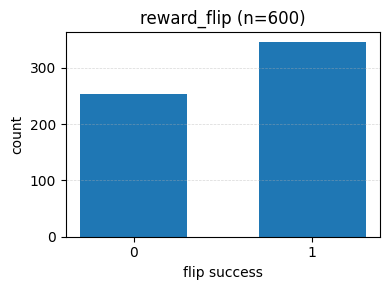

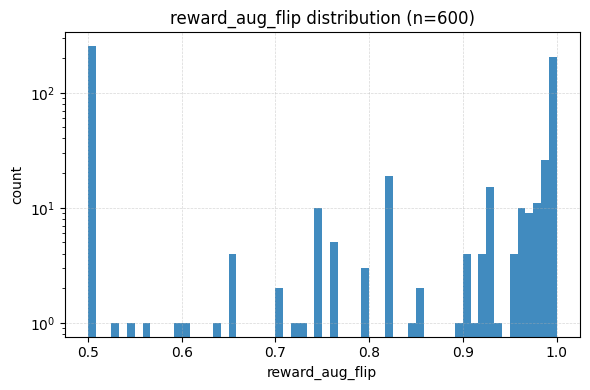

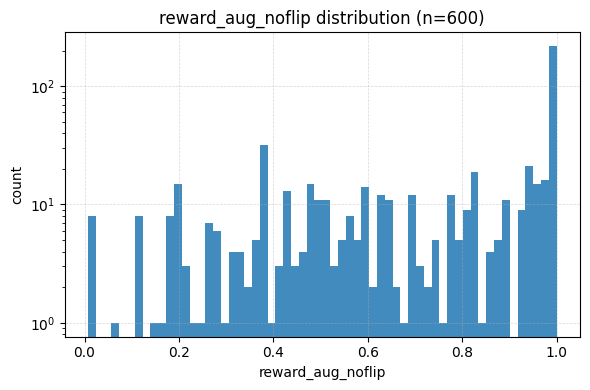

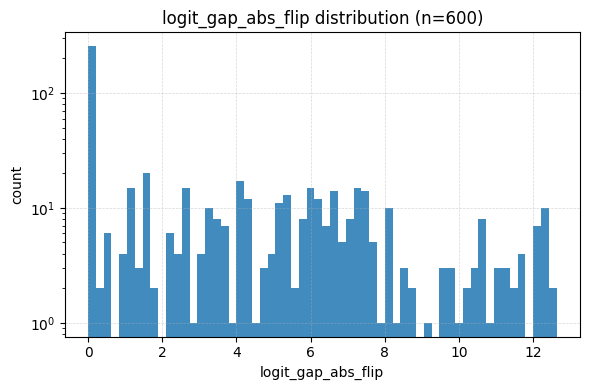

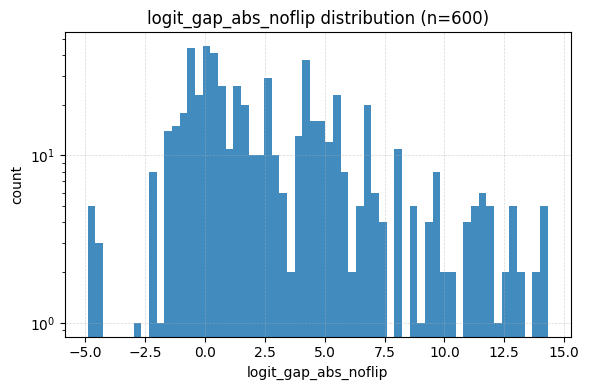

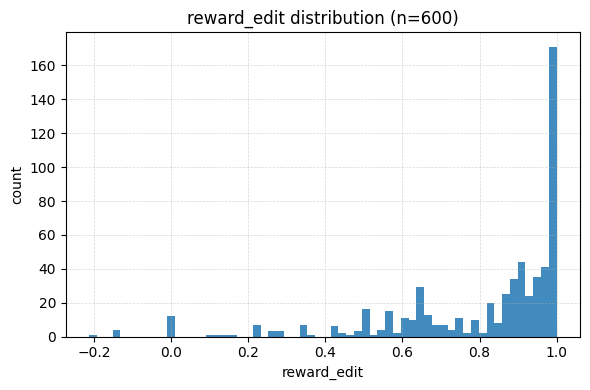

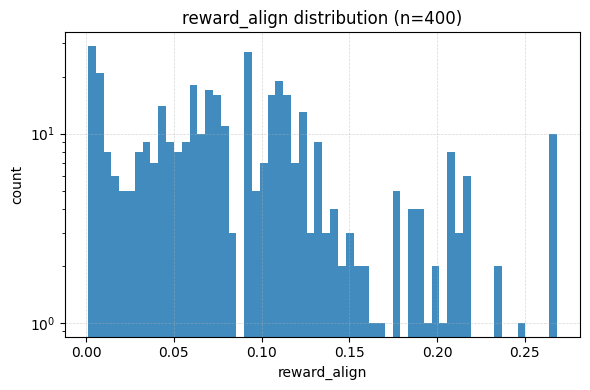

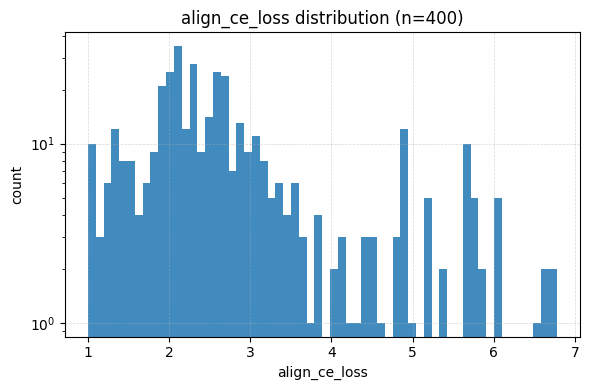


[info] quick stats:
reward_aug_flip {'n': 600, 'mean': 0.7600321264508899, 'p50': 0.8244619263765707, 'p90': 0.9997131459176125, 'p99': 0.999995626067745, 'min': 0.5, 'max': 0.9999967112509346}
reward_aug_noflip {'n': 600, 'mean': 0.7343224912410479, 'p50': 0.8395554031180712, 'p90': 0.9996540083968218, 'p99': 0.99999889840464, 'min': 0.007345826574477061, 'max': 0.9999993916409633}
logit_gap_abs_flip {'n': 600, 'mean': 3.2595719401041667, 'p50': 1.546875, 'p90': 8.15625, 'p99': 12.33984375, 'min': 0.0, 'max': 12.625}
logit_gap_abs_noflip {'n': 600, 'mean': 2.8993636067708333, 'p50': 1.65625, 'p90': 7.96875, 'p99': 13.71875, 'min': -4.90625, 'max': 14.3125}
reward_edit {'n': 600, 'mean': 0.8074280327206576, 'p50': 0.9076923076923077, 'p90': 1.0, 'p99': 1.0, 'min': -0.2127659574468086, 'max': 1.0}
reward_align {'n': 400, 'mean': 0.08715228177750287, 'p50': 0.07742419706827916, 'p90': 0.1837097233426655, 'p99': 0.2681037631991342, 'min': 0.001143723847773671, 'max': 0.2681037631991342}


In [27]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt


# =============== 配置区 ===============
root = Path("../data_qwen_reward_demo").resolve()

# 你关心的数值字段（按你示例里的 key）
NUM_KEYS = [
    "reward_flip",
    "reward_aug_flip",
    "reward_aug_noflip",
    "logit_gap_abs_flip",
    "logit_gap_abs_noflip",
    "reward_edit",
    "reward_align",
    "align_ce_loss",
]

# 一些直方图建议的裁剪范围（可按你数据分布再调）
CLIPS = {
    "reward_aug_flip": (-1, 1.2),
    "reward_aug_noflip": (-1, 1.2),
    "logit_gap_abs_flip": (-20, 30),
    "logit_gap_abs_noflip": (-20, 30),
    "reward_edit": (-1, 1),
    "reward_align": (-1, 5),
    "align_ce_loss": (0, 15),
}

LOGY = {
    "reward_aug_flip": True,
    "reward_aug_noflip": True,
    "logit_gap_abs_flip": True,
    "logit_gap_abs_noflip": True,
    "reward_align": True,
    "align_ce_loss": True,
}
# =====================================


def safe_float(x):
    """转 float 并过滤 nan/inf；失败返回 None。"""
    if x is None:
        return None
    try:
        v = float(x)
    except Exception:
        return None
    if not np.isfinite(v):
        return None
    return v


def iter_counterfactuals(ex):
    """
    从一条样本 ex 中迭代所有 counterfactual（跨语言）。
    兼容：counterfactual 是 dict(lang -> list[cf]) 或直接是 list[cf]（少见但防御）。
    """
    c = ex.get("counterfactual", None)
    if c is None:
        return

    if isinstance(c, dict):
        for lang, lst in c.items():
            if isinstance(lst, list):
                for cf in lst:
                    if isinstance(cf, dict):
                        yield lang, cf
    elif isinstance(c, list):
        for cf in c:
            if isinstance(cf, dict):
                yield None, cf


def plot_hist(name, data, bins=60, clip=None, logy=False):
    if not data:
        print(f"[skip] {name}: no data")
        return

    x = np.array(data, dtype=np.float64)
    if clip is not None:
        lo, hi = clip
        x = np.clip(x, lo, hi)

    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=bins, alpha=0.85)
    plt.title(f"{name} distribution (n={len(x)})")
    plt.xlabel(name)
    plt.ylabel("count")
    if logy:
        plt.yscale("log")  # 直方图长尾时常用 [web:1]
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_flip_bar(data):
    if not data:
        print("[skip] reward_flip: no data")
        return
    x = np.array(data, dtype=np.float64)

    # 兼容 reward_flip 是 0/1 或 bool 或其它数值：统一按 “==1” 统计成功
    c0 = int(np.sum(x == 0))
    c1 = int(np.sum(x == 1))

    plt.figure(figsize=(4, 3))
    plt.bar([0, 1], [c0, c1], width=0.6)
    plt.xticks([0, 1], ["0", "1"])
    plt.title(f"reward_flip (n={len(x)})")
    plt.xlabel("flip success")
    plt.ylabel("count")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


# =============== 主流程：读取与统计 ===============
jsonl_files = sorted(root.rglob("*.jsonl"))
print(f"[info] found {len(jsonl_files)} jsonl files under {root}")

vals = {k: [] for k in NUM_KEYS}
missing = {k: 0 for k in NUM_KEYS}

# 额外做一些按语言的统计（可选）
vals_by_lang = defaultdict(lambda: {k: [] for k in NUM_KEYS})
missing_by_lang = defaultdict(lambda: {k: 0 for k in NUM_KEYS})

num_lines = 0
num_cfs = 0

for fp in jsonl_files:
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            num_lines += 1
            try:
                ex = json.loads(line)
            except Exception:
                # 行级别坏数据直接跳过
                continue

            for lang, cf in iter_counterfactuals(ex):
                num_cfs += 1

                for k in NUM_KEYS:
                    v = safe_float(cf.get(k))
                    if v is None:
                        missing[k] += 1
                        missing_by_lang[lang][k] += 1
                    else:
                        vals[k].append(v)
                        vals_by_lang[lang][k].append(v)

print(f"[info] parsed lines={num_lines}, counterfactuals={num_cfs}")
print("[info] counts:", {k: len(v) for k, v in vals.items()})
print("[info] missing:", missing)

# 也可以看每种语言的样本量（如果你确实是多语言混在一起）
langs_sorted = sorted(vals_by_lang.keys(), key=lambda x: str(x))
print("[info] counterfactual counts by lang:",
      {str(lang): len(vals_by_lang[lang]['reward_flip']) for lang in langs_sorted})


# =============== 画图 ===============
plot_flip_bar(vals["reward_flip"])

for k in NUM_KEYS:
    if k == "reward_flip":
        continue
    plot_hist(
        k,
        vals[k],
        bins=60,
        clip=CLIPS.get(k),
        logy=LOGY.get(k, False),
    )


def describe(name, data):
    if not data:
        return None
    x = np.array(data, dtype=np.float64)
    return {
        "n": int(len(x)),
        "mean": float(np.mean(x)),
        "p50": float(np.percentile(x, 50)),
        "p90": float(np.percentile(x, 90)),
        "p99": float(np.percentile(x, 99)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    }

print("\n[info] quick stats:")
for k in NUM_KEYS:
    if k == "reward_flip":
        continue
    d = describe(k, vals[k])
    print(k, d)

[info] found 6 jsonl files under /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo
[info] parsed lines=60, counterfactuals=600, cfs_with_reward_flip=600
[info] counts: {'reward_flip': 600, 'reward_aug_flip': 346, 'reward_aug_noflip': 254, 'logit_gap_abs_flip': 346, 'logit_gap_abs_noflip': 254, 'reward_edit': 600, 'reward_align': 400, 'align_ce_loss': 400}
[info] missing (after applying flip filters where needed): {'reward_flip': 0, 'reward_aug_flip': 0, 'reward_aug_noflip': 0, 'logit_gap_abs_flip': 0, 'logit_gap_abs_noflip': 0, 'reward_edit': 0, 'reward_align': 200, 'align_ce_loss': 200}
[info] counterfactual counts by lang: {'de': 200, 'en': 200, 'zh': 200}


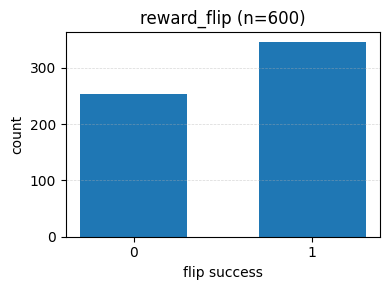

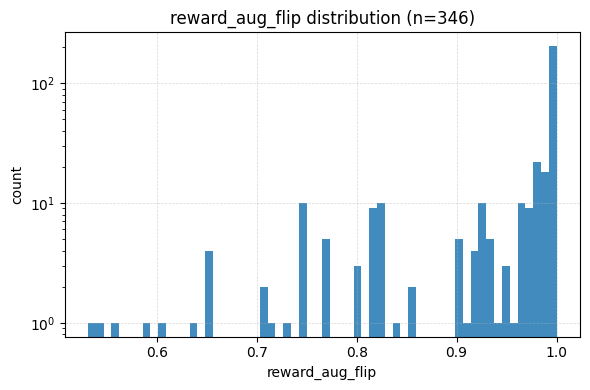

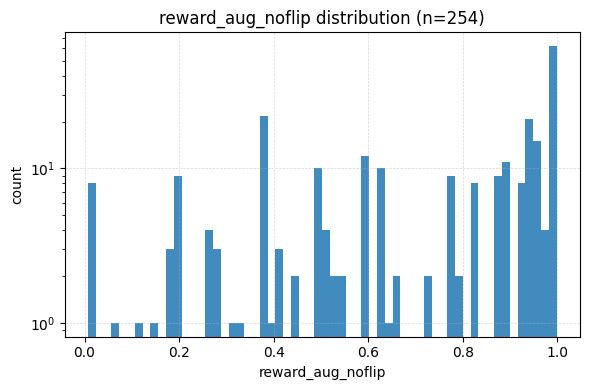

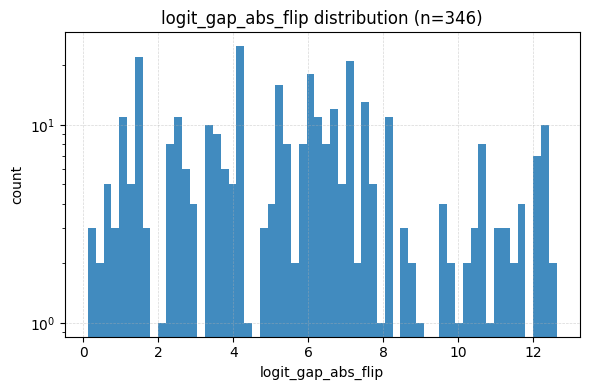

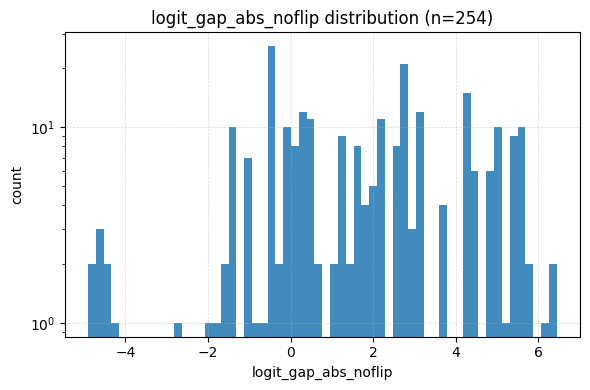

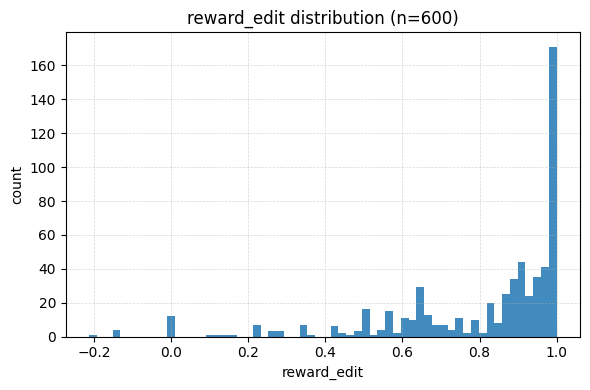

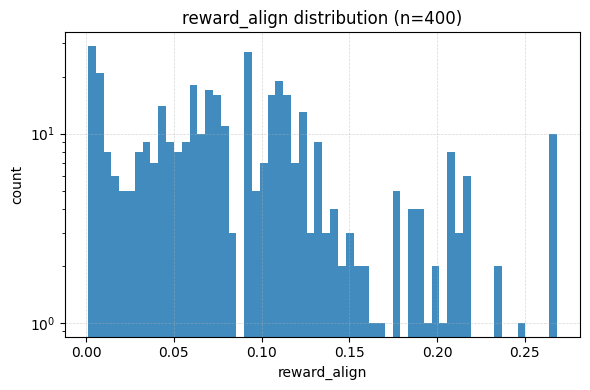

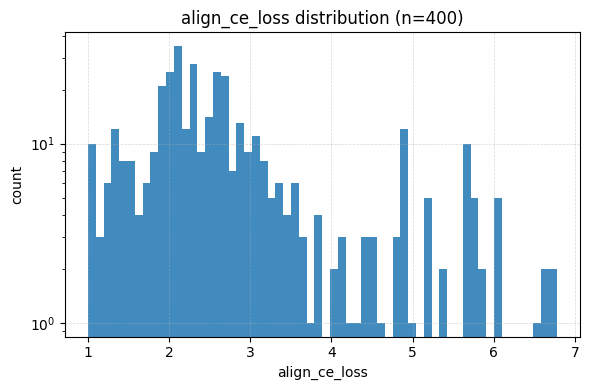


[info] quick stats:
reward_aug_flip {'n': 346, 'mean': 0.9509227626316011, 'p50': 0.996671946482217, 'p90': 0.9999778743309043, 'p99': 0.999995626067745, 'min': 0.5312093733737563, 'max': 0.9999967112509346}
reward_aug_noflip {'n': 254, 'mean': 0.7161591009021022, 'p50': 0.8670357598021706, 'p90': 0.9933071490757153, 'p99': 0.9972926013641705, 'min': 0.007345826574477061, 'max': 0.9984021545059827}
logit_gap_abs_flip {'n': 346, 'mean': 5.652436890354046, 'p50': 5.703125, 'p90': 10.71875, 'p99': 12.33984375, 'min': 0.125, 'max': 12.625}
logit_gap_abs_noflip {'n': 254, 'mean': 1.767224409448819, 'p50': 1.875, 'p90': 5.0, 'p99': 5.92625, 'min': -4.90625, 'max': 6.4375}
reward_edit {'n': 600, 'mean': 0.8074280327206576, 'p50': 0.9076923076923077, 'p90': 1.0, 'p99': 1.0, 'min': -0.2127659574468086, 'max': 1.0}
reward_align {'n': 400, 'mean': 0.08715228177750287, 'p50': 0.07742419706827916, 'p90': 0.1837097233426655, 'p99': 0.2681037631991342, 'min': 0.001143723847773671, 'max': 0.268103763

In [25]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt


# =============== 配置区 ===============
root = Path("../data_qwen_reward_demo").resolve()

# 你关心的数值字段（按你示例里的 key）
NUM_KEYS = [
    "reward_flip",
    "reward_aug_flip",
    "reward_aug_noflip",
    "logit_gap_abs_flip",
    "logit_gap_abs_noflip",
    "reward_edit",
    "reward_align",
    "align_ce_loss",
]

# 这四个 key 画图/统计时要按“对的情况”过滤
# flip-only: 只在 flip 成功时累计
ONLY_WHEN_FLIP_1 = {
    "reward_aug_flip",
    "logit_gap_abs_flip",
}
# noflip-only: 只在 flip 失败时累计
ONLY_WHEN_FLIP_0 = {
    "reward_aug_noflip",
    "logit_gap_abs_noflip",
}

# 一些直方图建议的裁剪范围（按你数据分布再调）
CLIPS = {
    "reward_aug_flip": (0, 1.2),
    "reward_aug_noflip": (0, 1.2),
    "logit_gap_abs_flip": (-20, 30),
    "logit_gap_abs_noflip": (-20, 30),
    "reward_edit": (-1, 1),
    "reward_align": (0, 5),
    "align_ce_loss": (0, 15),
}

LOGY = {
    "reward_aug_flip": True,
    "reward_aug_noflip": True,
    "logit_gap_abs_flip": True,
    "logit_gap_abs_noflip": True,
    "reward_align": True,
    "align_ce_loss": True,
}
# =====================================


def safe_float(x):
    """转 float 并过滤 nan/inf；失败返回 None。"""
    if x is None:
        return None
    try:
        v = float(x)
    except Exception:
        return None
    if not np.isfinite(v):
        return None
    return v


def safe_int01(x):
    """把 reward_flip 规整成 0/1；失败返回 None。"""
    v = safe_float(x)
    if v is None:
        return None
    # 兼容 bool / 0.0/1.0 / 其他数值
    if v == 1.0:
        return 1
    if v == 0.0:
        return 0
    # 如果是其它值，按阈值近似（可按你的数据情况删掉）
    return 1 if v > 0.5 else 0


def iter_counterfactuals(ex):
    """
    从一条样本 ex 中迭代所有 counterfactual（跨语言）。
    兼容：counterfactual 是 dict(lang -> list[cf]) 或直接是 list[cf]（少见但防御）。
    """
    c = ex.get("counterfactual", None)
    if c is None:
        return

    if isinstance(c, dict):
        for lang, lst in c.items():
            if isinstance(lst, list):
                for cf in lst:
                    if isinstance(cf, dict):
                        yield lang, cf
    elif isinstance(c, list):
        for cf in c:
            if isinstance(cf, dict):
                yield None, cf


def plot_hist(name, data, bins=60, clip=None, logy=False):
    if not data:
        print(f"[skip] {name}: no data")
        return

    x = np.array(data, dtype=np.float64)
    if clip is not None:
        lo, hi = clip
        x = np.clip(x, lo, hi)

    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=bins, alpha=0.85)
    plt.title(f"{name} distribution (n={len(x)})")
    plt.xlabel(name)
    plt.ylabel("count")
    if logy:
        plt.yscale("log")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_flip_bar(data):
    if not data:
        print("[skip] reward_flip: no data")
        return
    x = np.array(data, dtype=np.float64)
    c0 = int(np.sum(x == 0))
    c1 = int(np.sum(x == 1))

    plt.figure(figsize=(4, 3))
    plt.bar([0, 1], [c0, c1], width=0.6)
    plt.xticks([0, 1], ["0", "1"])
    plt.title(f"reward_flip (n={len(x)})")
    plt.xlabel("flip success")
    plt.ylabel("count")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


def describe(name, data):
    if not data:
        return None
    x = np.array(data, dtype=np.float64)
    return {
        "n": int(len(x)),
        "mean": float(np.mean(x)),
        "p50": float(np.percentile(x, 50)),
        "p90": float(np.percentile(x, 90)),
        "p99": float(np.percentile(x, 99)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    }


def should_take_key_given_flip(key, flip01):
    """
    决定某个 key 是否在当前 cf 上累计。
    - key in ONLY_WHEN_FLIP_1: 只在 flip==1 时累计
    - key in ONLY_WHEN_FLIP_0: 只在 flip==0 时累计
    - else: 不做过滤，flip 不影响
    """
    if key in ONLY_WHEN_FLIP_1:
        return flip01 == 1
    if key in ONLY_WHEN_FLIP_0:
        return flip01 == 0
    return True


# =============== 主流程：读取与统计 ===============
jsonl_files = sorted(root.rglob("*.jsonl"))
print(f"[info] found {len(jsonl_files)} jsonl files under {root}")

vals = {k: [] for k in NUM_KEYS}
missing = {k: 0 for k in NUM_KEYS}

vals_by_lang = defaultdict(lambda: {k: [] for k in NUM_KEYS})
missing_by_lang = defaultdict(lambda: {k: 0 for k in NUM_KEYS})

num_lines = 0
num_cfs = 0
num_cfs_with_flip = 0

for fp in jsonl_files:
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            num_lines += 1
            try:
                ex = json.loads(line)
            except Exception:
                continue

            for lang, cf in iter_counterfactuals(ex):
                num_cfs += 1

                flip01 = safe_int01(cf.get("reward_flip"))
                if flip01 is not None:
                    num_cfs_with_flip += 1

                # 先处理 reward_flip 本身：不做过滤（否则你没法画 flip bar）
                vflip = safe_float(cf.get("reward_flip"))
                if vflip is None:
                    missing["reward_flip"] += 1
                    missing_by_lang[lang]["reward_flip"] += 1
                else:
                    vals["reward_flip"].append(vflip)
                    vals_by_lang[lang]["reward_flip"].append(vflip)

                # 其余 key：按 flip 过滤规则累计
                for k in NUM_KEYS:
                    if k == "reward_flip":
                        continue

                    # 如果该 key 需要 flip 条件，但 flip 缺失，则直接视为 missing（因为无法判断是否该累计）
                    if (k in ONLY_WHEN_FLIP_1 or k in ONLY_WHEN_FLIP_0) and flip01 is None:
                        missing[k] += 1
                        missing_by_lang[lang][k] += 1
                        continue

                    if not should_take_key_given_flip(k, flip01):
                        # 不属于“对的情况”，跳过，不计 missing
                        continue

                    v = safe_float(cf.get(k))
                    if v is None:
                        missing[k] += 1
                        missing_by_lang[lang][k] += 1
                    else:
                        vals[k].append(v)
                        vals_by_lang[lang][k].append(v)

print(f"[info] parsed lines={num_lines}, counterfactuals={num_cfs}, cfs_with_reward_flip={num_cfs_with_flip}")
print("[info] counts:", {k: len(v) for k, v in vals.items()})
print("[info] missing (after applying flip filters where needed):", missing)

langs_sorted = sorted(vals_by_lang.keys(), key=lambda x: str(x))
print("[info] counterfactual counts by lang:",
      {str(lang): len(vals_by_lang[lang]["reward_flip"]) for lang in langs_sorted})


# =============== 画图 ===============
plot_flip_bar(vals["reward_flip"])

for k in NUM_KEYS:
    if k == "reward_flip":
        continue
    plot_hist(
        k,
        vals[k],
        bins=60,
        clip=CLIPS.get(k),
        logy=LOGY.get(k, False),
    )

print("\n[info] quick stats:")
for k in NUM_KEYS:
    if k == "reward_flip":
        continue
    d = describe(k, vals[k])
    print(k, d)


In [26]:
import json
from pathlib import Path

import numpy as np

root = Path("../data_qwen_reward_demo").resolve()

def iter_gen0_cfs(ex):
    """
    Yield gen_id==0 counterfactuals across languages.
    Supports:
      - counterfactual: {lang: [cf, ...], ...}
      - counterfactual: [cf, ...]
    Selection rule:
      - Prefer the one with cf['gen_id']==0 if present.
      - Otherwise fallback to the 0-th element of the list.
    """
    c = ex.get("counterfactual", None)
    if c is None:
        return

    def pick_gen0(lst):
        if not isinstance(lst, list) or len(lst) == 0:
            return None
        # prefer explicit gen_id == 0
        for cf in lst:
            if isinstance(cf, dict) and cf.get("gen_id", None) == 0:
                return cf
        # fallback: first element
        if isinstance(lst[0], dict):
            return lst[0]
        return None

    if isinstance(c, dict):
        for lang, lst in c.items():
            cf0 = pick_gen0(lst)
            if cf0 is not None:
                yield lang, cf0
    elif isinstance(c, list):
        cf0 = pick_gen0(c)
        if cf0 is not None:
            yield None, cf0


def safe_flip01(v):
    """
    Convert reward_flip to 0/1.
    Returns None if missing/unparseable.
    """
    if v is None:
        return None
    try:
        x = float(v)
    except Exception:
        return None
    if not np.isfinite(x):
        return None
    if x == 1.0:
        return 1
    if x == 0.0:
        return 0
    # tolerate weird values
    return 1 if x > 0.5 else 0


jsonl_files = sorted(root.rglob("*.jsonl"))
print(f"[info] found {len(jsonl_files)} jsonl files under {root}")

rows_out = []
for fp in jsonl_files:
    n_used = 0
    n_flip1 = 0
    n_missing = 0

    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                ex = json.loads(line)
            except Exception:
                continue

            any_found = False
            for lang, cf0 in iter_gen0_cfs(ex):
                any_found = True
                flip01 = safe_flip01(cf0.get("reward_flip"))
                if flip01 is None:
                    n_missing += 1
                else:
                    n_used += 1
                    n_flip1 += int(flip01 == 1)

            if not any_found:
                n_missing += 1

    flip_rate = (n_flip1 / n_used) if n_used > 0 else float("nan")
    rows_out.append((str(fp), n_used, n_flip1, n_missing, flip_rate))

# print nicely
rows_out.sort(key=lambda x: (np.nan_to_num(x[4], nan=-1), x[1]), reverse=True)

print("\nfile\t\t\t\t n_used\t n_flip1\t n_missing\t flip_rate")
for path, n_used, n_flip1, n_missing, fr in rows_out:
    print(f"{path}\t{n_used}\t{n_flip1}\t{n_missing}\t{fr:.4f}" if np.isfinite(fr) else
          f"{path}\t{n_used}\t{n_flip1}\t{n_missing}\tNaN")


[info] found 6 jsonl files under /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo

file				 n_used	 n_flip1	 n_missing	 flip_rate
/root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/sib200/train/en_Qwen3-8B_260202_184433.jsonl	10	7	0	0.7000
/root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/xnli/train/en_Qwen3-8B_260202_193918.jsonl	10	7	0	0.7000
/root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/sib200/train/zh_Qwen3-8B_260202_184515.jsonl	10	6	0	0.6000
/root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/sib200/train/de_Qwen3-8B_260202_184446.jsonl	10	5	0	0.5000
/root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/xnli/train/zh_Qwen3-8B_260202_200552.jsonl	10	5	0	0.5000
/root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/xnli/train/de_Qwen3-8B_260202_194721.jsonl	10	4	0	0.4000
